# Notebook 03 — Classification

**What this notebook does:**
1. Builds slope/rate features per patient from their visit history
2. Trains XGBoost 3-class classifier: CN vs MCI vs Dementia
3. Trains binary XGBoost: MCI→Dementia conversion (AUC target >0.80)
4. SHAP feature importance (install with `pip install shap` — optional)
5. Saves confusion matrix + ROC curve to results/metrics/

**Runtime:** ~2 min  |  **Prerequisites:** data/raw/ADNIMERGE.csv

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve, accuracy_score)
from xgboost import XGBClassifier

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

np.random.seed(42)
os.makedirs('results/metrics', exist_ok=True)

BG = '#0d1117'
print('Imports OK')

Imports OK


In [11]:
# ── Cell 2: Load & engineer per-patient features ─────────────────────
#
# For classification we work at PATIENT level (one row per RID),
# not visit level. We extract slope/rate features that capture
# how fast each patient is declining.

df = pd.read_csv('data/raw/ADNIMERGE.csv')
df['Hippocampus'] = df['Hippocampus'].fillna(df['Hippocampus'].mean())
df['APOE4']       = df['APOE4'].fillna(df['APOE4'].median())
df['Education']   = df['Education'].fillna(df['Education'].median())
df['Gender_num']  = (df['Gender'] == 'Male').astype(float)
df = df.sort_values(['RID','visit_num'])

print(f'Loaded: {df.shape[0]} rows, {df.RID.nunique()} patients')
print(df['DX'].value_counts())

Loaded: 14314 rows, 4722 patients
DX
MCI         5665
CN          4981
Dementia    2642
Name: count, dtype: int64


In [12]:
# ── Cell 3: Build one row per patient with slope features ─────────────
records = []

for rid, g in df.dropna(subset=['DX','visit_num']).groupby('RID'):
    g = g.sort_values('visit_num').reset_index(drop=True)
    if len(g) < 2:
        continue

    mmse_vals  = g['MMSE'].dropna().values
    hippo_vals = g['Hippocampus'].values

    # Slope = linear regression coefficient over visits
    vis = g['visit_num'].values
    mmse_slope  = np.polyfit(vis, g['MMSE'].ffill().values, 1)[0]
    hippo_slope = np.polyfit(vis, hippo_vals, 1)[0]

    records.append({
        'RID':              rid,
        # Static features
        'APOE4':            g['APOE4'].iloc[0],
        'Education':        g['Education'].iloc[0],
        'Gender_num':       g['Gender_num'].iloc[0],
        'n_visits':         len(g),
        # Baseline values
        'MMSE_baseline':    g['MMSE'].iloc[0],
        'Hippo_baseline':   hippo_vals[0],
        # Last known values
        'MMSE_last':        g['MMSE'].iloc[-1],
        'Hippo_last':       hippo_vals[-1],
        # Change from baseline
        'MMSE_total_drop':  g['MMSE'].iloc[0] - g['MMSE'].iloc[-1],
        'Hippo_total_drop': hippo_vals[0] - hippo_vals[-1],
        # Slopes (rate of change per visit)
        'MMSE_slope':       mmse_slope,
        'Hippo_slope':      hippo_slope,
        # Final DX (classification target)
        'DX_final':         g['DX'].iloc[-1],
        # First DX (for MCI→Dementia converter)
        'DX_first':         g['DX'].iloc[0],
        # Did they convert MCI→Dementia?
        'converted':        int(g['DX'].iloc[0]=='MCI' and 'Dementia' in g['DX'].values),
    })

pat_df = pd.DataFrame(records)
print(f'Patient-level dataframe: {pat_df.shape}')
print(pat_df['DX_final'].value_counts())
print(f"\nMCI→Dementia converters: {pat_df['converted'].sum()} / {(pat_df['DX_first']=='MCI').sum()} MCI patients")

Patient-level dataframe: (901, 16)
DX_final
Dementia    367
MCI         325
CN          209
Name: count, dtype: int64

MCI→Dementia converters: 185 / 497 MCI patients


In [22]:
# ── Cell 4: 3-class classifier (CN / MCI / Dementia) ─────────────────
FEAT_3CLASS = ['APOE4','Education','Gender_num','n_visits',
               'MMSE_baseline','Hippo_baseline','MMSE_last','Hippo_last',
               'MMSE_total_drop','Hippo_total_drop','MMSE_slope','Hippo_slope']

clf3_df = pat_df.dropna(subset=['DX_final']+FEAT_3CLASS).copy()
clf3_df = clf3_df[clf3_df['DX_final'].isin(['CN','MCI','Dementia'])]

X3 = clf3_df[FEAT_3CLASS].values.astype(np.float32)
le = LabelEncoder()
y3 = le.fit_transform(clf3_df['DX_final'])
print(f'3-class dataset: {X3.shape}  classes: {le.classes_}')

xgb3 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

# 5-fold cross-validation
cv3    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb3, X3, y3, cv=cv3, scoring='accuracy')
print(f'\n5-fold CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}')

# Final fit on full data for feature importance
from sklearn.model_selection import cross_val_predict

y3_pred = cross_val_predict(xgb3, X3, y3, cv=cv3)
xgb3.fit(X3, y3)
print('\nCross-validated classification report:\n')
print(classification_report(y3, y3_pred, target_names=le.classes_))

3-class dataset: (901, 12)  classes: ['CN' 'Dementia' 'MCI']

5-fold CV accuracy: 0.766 ± 0.013

Cross-validated classification report:

              precision    recall  f1-score   support

          CN       0.71      0.74      0.73       209
    Dementia       0.84      0.89      0.87       367
         MCI       0.71      0.64      0.67       325

    accuracy                           0.77       901
   macro avg       0.75      0.76      0.75       901
weighted avg       0.76      0.77      0.76       901



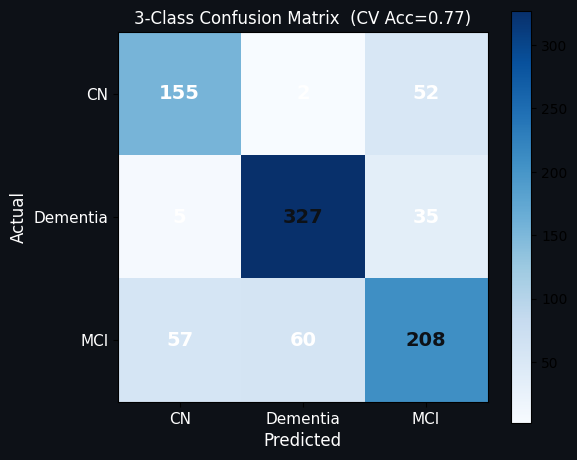

Saved → results/metrics/confusion_matrix.png


In [23]:
# ── Cell 5: Confusion matrix plot ─────────────────────────────────────
cm = confusion_matrix(y3, y3_pred)
fig, ax = plt.subplots(figsize=(6,5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, color='white', fontsize=11)
ax.set_yticklabels(le.classes_, color='white', fontsize=11)
ax.set_xlabel('Predicted', color='white', fontsize=12)
ax.set_ylabel('Actual',    color='white', fontsize=12)
ax.set_title(f'3-Class Confusion Matrix  (CV Acc={scores.mean():.2f})',
             color='white', fontsize=12)

for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] < cm.max()/2 else '#0d1117',
                fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('results/metrics/confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/confusion_matrix.png')

In [24]:
# ── Cell 6: Binary MCI→Dementia converter (AUC target >0.80) ──────────
mci_df = pat_df[pat_df['DX_first']=='MCI'].dropna(subset=FEAT_3CLASS).copy()
print(f'MCI patients for conversion task: {len(mci_df)}')
print(f'  Converters (MCI→Dementia): {mci_df["converted"].sum()}')
print(f'  Non-converters:            {(mci_df["converted"]==0).sum()}')

X_mci = mci_df[FEAT_3CLASS].values.astype(np.float32)
y_mci = mci_df['converted'].values

xgb_bin = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_mci==0).sum() / max((y_mci==1).sum(), 1),  # handle imbalance
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

cv_bin = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(xgb_bin, X_mci, y_mci, cv=cv_bin, scoring='roc_auc')
print(f'\nMCI→Dementia AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')
print(f'Target AUC > 0.80 → {"✓ PASS" if auc_scores.mean()>0.80 else "borderline — see note"}')

# Fit for ROC curve
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predictions (NO leakage)
prob_mci = cross_val_predict(
    xgb_bin,
    X_mci,
    y_mci,
    cv=cv_bin,
    method='predict_proba'
)[:,1]

full_auc = roc_auc_score(y_mci, prob_mci)
xgb_bin.fit(X_mci, y_mci)
print("Done")

MCI patients for conversion task: 497
  Converters (MCI→Dementia): 185
  Non-converters:            312

MCI→Dementia AUC: 0.900 ± 0.031
Target AUC > 0.80 → ✓ PASS
Done


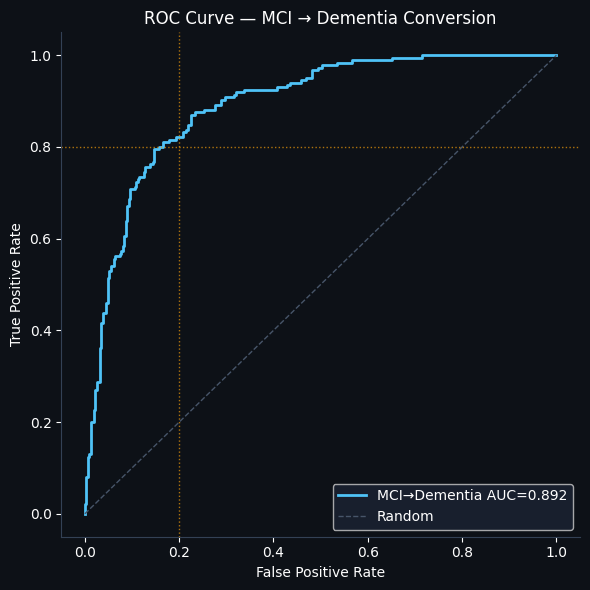

Saved → results/metrics/roc_curves.png


In [25]:
# ── Cell 7: ROC curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_mci, prob_mci)

fig, ax = plt.subplots(figsize=(6,6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(fpr, tpr, color='#4fc3f7', lw=2, label=f'MCI→Dementia AUC={full_auc:.3f}')
ax.plot([0,1],[0,1], '--', color='#475569', lw=1, label='Random')
ax.axhline(0.80, color='#f59e0b', linestyle=':', lw=1, alpha=0.7)
ax.axvline(0.20, color='#f59e0b', linestyle=':', lw=1, alpha=0.7)

ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate',  color='white')
ax.set_title('ROC Curve — MCI → Dementia Conversion', color='white')
ax.legend(facecolor='#1c2333', labelcolor='white')
ax.tick_params(colors='white')
for sp in ['bottom','left']:  ax.spines[sp].set_color('#334155')
for sp in ['top','right']:    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('results/metrics/roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/roc_curves.png')

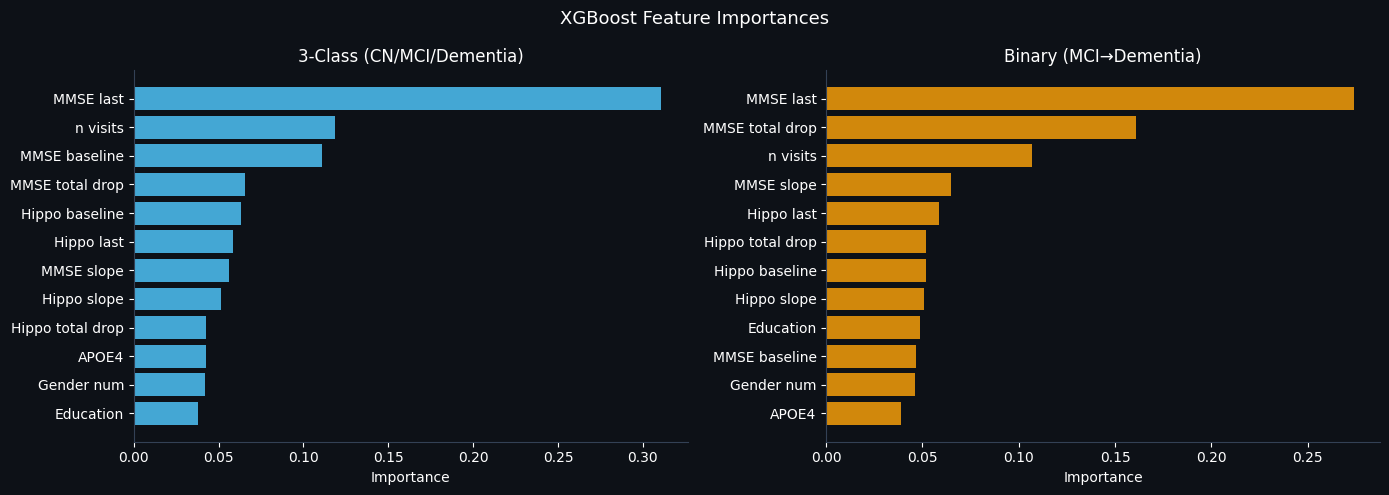

Saved → results/metrics/feature_importance.png


In [26]:
# ── Cell 8: Feature importance (both models) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

for ax, model, title, color in zip(
    axes,
    [xgb3, xgb_bin],
    ['3-Class (CN/MCI/Dementia)', 'Binary (MCI→Dementia)'],
    ['#4fc3f7', '#f59e0b']
):
    ax.set_facecolor(BG)
    imp  = model.feature_importances_
    idx  = np.argsort(imp)
    feat_names = [f.replace('_',' ') for f in FEAT_3CLASS]
    ax.barh([feat_names[i] for i in idx], imp[idx], color=color, alpha=0.85)
    ax.set_xlabel('Importance', color='white')
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    for sp in ['bottom','left']:  ax.spines[sp].set_color('#334155')
    for sp in ['top','right']:    ax.spines[sp].set_visible(False)

plt.suptitle('XGBoost Feature Importances', color='white', fontsize=13)
plt.tight_layout()
plt.savefig('results/metrics/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/feature_importance.png')

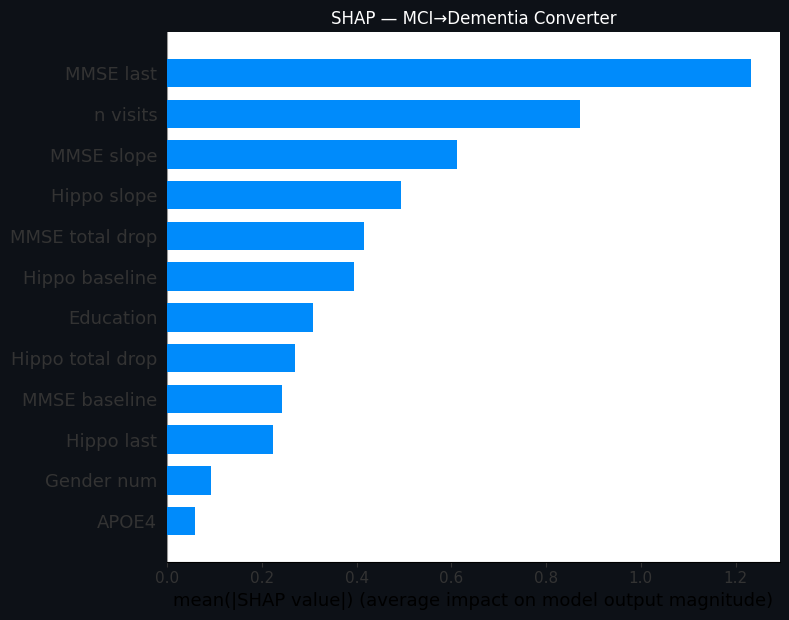

SHAP saved → results/metrics/shap_importance.png


In [27]:
# ── Cell 9: SHAP values (optional — only if shap installed) ───────────
try:
    import shap
    shap.initjs()

    explainer = shap.TreeExplainer(xgb_bin)
    shap_vals = explainer.shap_values(X_mci)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor(BG)
    shap.summary_plot(shap_vals, X_mci,
                      feature_names=[f.replace('_',' ') for f in FEAT_3CLASS],
                      show=False, plot_type='bar')
    plt.title('SHAP — MCI→Dementia Converter', color='white')
    plt.tight_layout()
    plt.savefig('results/metrics/shap_importance.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()
    print('SHAP saved → results/metrics/shap_importance.png')

except ImportError:
    print('SHAP not installed — skipping.  Run:  pip install shap')
    print('Feature importance bar chart saved instead (Cell 8).')

In [28]:
# ── Cell 10: Save all classification metrics ──────────────────────────
# Load existing lstm_metrics and append classification metrics
try:
    with open('results/metrics/lstm_metrics.json') as f:
        all_metrics = json.load(f)
except FileNotFoundError:
    all_metrics = {}

all_metrics.update({
    'clf3_cv_accuracy':    round(float(scores.mean()),   4),
    'clf3_cv_accuracy_std':round(float(scores.std()),    4),
    'mci_conv_auc_cv':     round(float(auc_scores.mean()),4),
    'mci_conv_auc_cv_std': round(float(auc_scores.std()),4),
})

with open('results/metrics/lstm_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print('='*50)
print('CLASSIFICATION RESULTS SUMMARY')
print('='*50)
print(f'3-Class CV Accuracy : {scores.mean():.3f} ± {scores.std():.3f}')
print(f'  Target 75-80%     → {"✓ PASS" if scores.mean()>=0.75 else "✗ FAIL"}')
print()
print(f'MCI→Dementia AUC    : {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')
print(f'  Target > 0.80     → {"✓ PASS" if auc_scores.mean()>0.80 else "✗ FAIL"}')
print()
print('Files saved:')
print('  results/metrics/confusion_matrix.png')
print('  results/metrics/roc_curves.png')
print('  results/metrics/feature_importance.png')
print('  results/metrics/lstm_metrics.json  (updated)')
print()
print('Next: 04_visualization.ipynb  (Wednesday)')

CLASSIFICATION RESULTS SUMMARY
3-Class CV Accuracy : 0.766 ± 0.013
  Target 75-80%     → ✓ PASS

MCI→Dementia AUC    : 0.900 ± 0.031
  Target > 0.80     → ✓ PASS

Files saved:
  results/metrics/confusion_matrix.png
  results/metrics/roc_curves.png
  results/metrics/feature_importance.png
  results/metrics/lstm_metrics.json  (updated)

Next: 04_visualization.ipynb  (Wednesday)
